<a href="https://colab.research.google.com/github/pragyadeb/Alzheimer-Augmentation/blob/main/AlzAugment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip /path/to/your/file.zip -d /content/dataset.zip

unzip:  cannot find or open /path/to/your/file.zip, /path/to/your/file.zip.zip or /path/to/your/file.zip.ZIP.


In [ ]:
import zipfile
import os

zip_path = "/content/dataset.zip"
extract_path = "/content/dataset/unzipped"

# Create target directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
for dirname, _, filenames in os.walk('/content/dataset/unzipped'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/content/dataset/unzipped/Alzheimer MRI Disease Classification Dataset/README.md
/content/dataset/unzipped/Alzheimer MRI Disease Classification Dataset/Data/test-00000-of-00001-44110b9df98c5585.parquet
/content/dataset/unzipped/Alzheimer MRI Disease Classification Dataset/Data/train-00000-of-00001-c08a401c53fe5312.parquet


In [ ]:
import pandas as pd

# Update the paths to match your Colab unzipped directory
df = pd.read_parquet('/content/dataset/unzipped/Alzheimer MRI Disease Classification Dataset/Data/train-00000-of-00001-c08a401c53fe5312.parquet')

val_data = pd.read_parquet('/content/dataset/unzipped/Alzheimer MRI Disease Classification Dataset/Data/test-00000-of-00001-44110b9df98c5585.parquet')

print(df.head())
print(val_data.head())


                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0


In [ ]:
print(df.head(5))
print("*"*100)
print(val_data.head(5))
print("*"*100)
print(df.shape,val_data.shape)

                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
****************************************************************************************************
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
****************************************************************************************************
(5120, 2) (1280, 2)


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np # Import numpy

def convert_to_format(bytes_df):
    img_arr=np.frombuffer(bytes_df,dtype=np.uint8) # frombuffer is used to convert the bytes to np.array
    img=cv2.imdecode(img_arr,cv2.IMREAD_COLOR)    # here cv2 imdecode is used for readblity formate and IMREAD_COLOR is used for rgb color format image
    return img

images=[]

def get_img(df):
    images=[]
    for i in range(len(df)):
        inputt=df.iloc[i]['image']['bytes']
        cv_data=convert_to_format(inputt)
        images.append(cv_data)
    return images

images=get_img(df)

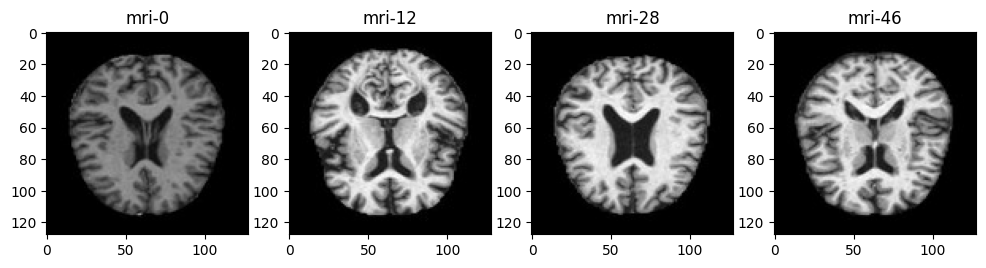

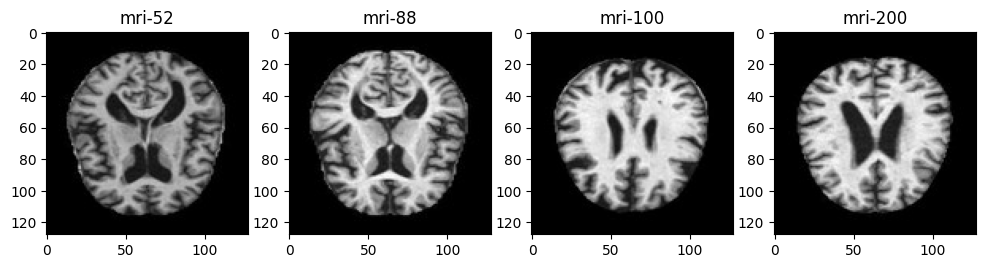

In [ ]:
plt.figure(figsize=(12,9))
plt.subplot(241)
plt.imshow(cv2.cvtColor(images[0],cv2.COLOR_BGR2RGB))
plt.title('mri-0')
# should use it kerneal die because of ram by using the cv lib

plt.subplot(242)
plt.imshow(cv2.cvtColor(images[12],cv2.COLOR_BGR2RGB))
plt.title('mri-12')


plt.subplot(243)
plt.imshow(cv2.cvtColor(images[28],cv2.COLOR_BGR2RGB))
plt.title('mri-28')
plt.subplot(244)
plt.imshow(cv2.cvtColor(images[46],cv2.COLOR_BGR2RGB))
plt.title('mri-46')
plt.show() # should use it kerneal die because of ram by using the cv lib

plt.figure(figsize=(12,9))
plt.subplot(241)
plt.imshow(cv2.cvtColor(images[52],cv2.COLOR_BGR2RGB))
plt.title('mri-52')

plt.subplot(242)
plt.imshow(cv2.cvtColor(images[88],cv2.COLOR_BGR2RGB))
plt.title('mri-88')


plt.subplot(243)
plt.imshow(cv2.cvtColor(images[100],cv2.COLOR_BGR2RGB))
plt.title('mri-100')

plt.subplot(244)
plt.imshow(cv2.cvtColor(images[200],cv2.COLOR_BGR2RGB))
plt.title('mri-200')
plt.show()

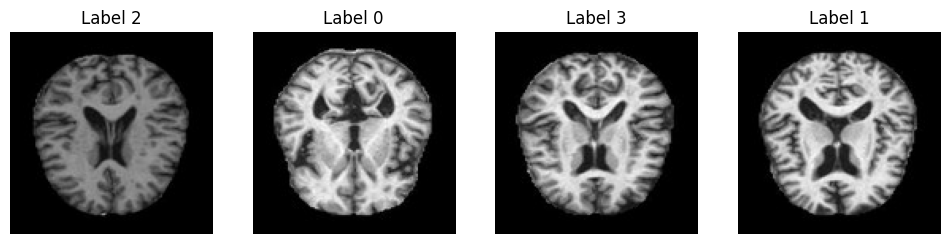

In [ ]:
def get_images_per_label(df):
    selected_images = {}  # Dictionary to store one image per label

    for i in range(len(df)):
        label = df.iloc[i]['label']  # Get the label of the current image
        if label not in selected_images:  # Check if this label is already stored
            inputt = df.iloc[i]['image']['bytes']
            cv_data = convert_to_format(inputt)
            selected_images[label] = cv_data  # Store the first found image for this label
        if len(selected_images) == 4:  # Stop when we have all 4 labels
            break

    return selected_images  # Return dictionary with 4 images (one per label)

# Get one MRI image per label
mri_images = get_images_per_label(df)

# Display the images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i, (label, img) in enumerate(mri_images.items()):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Label {label}")
    axes[i].axis("off")
plt.show()

In [ ]:
df['label'].value_counts()

,count
label,
2,2566
3,1781
0,724
1,49


In [ ]:
# now need to agmented only classed o and 1 data
df_agu=df[df['label'].isin([0,1])]
df_other=df[df['label'].isin([2,3])]

In [ ]:
##PreProcessing - Data AUGMENTATION

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import io
from sklearn.model_selection import train_test_split

# Function to convert image bytes to normalized numpy array
def load_and_preprocess_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('L')  # Convert to grayscale # here L remover rgb
    img = img.resize((128, 128))  # Resize
    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=-1)  # Add channel dimension
    return img_array

    # Separate df_agu (only class 0 and 1) and df_other (class 2 and 3)
df_agu = df[df['label'].isin([0,1])].copy()
df_other = df[df['label'].isin([2,3])].copy()

# Convert images in df_other to image_arr with normalization
df_other['image_arr'] = df_other['image'].apply(lambda img_dict: load_and_preprocess_image(img_dict['bytes']))

#  Augmentation for df_agu
datagen = ImageDataGenerator(
    rotation_range=50, width_shift_range=0.3, height_shift_range=0.3,
    shear_range=0.4, zoom_range=0.6, horizontal_flip=True,fill_mode="nearest"
)

augmented_images = []
augmented_labels = []
# Determine class counts
label_counts = df_agu['label'].value_counts()
max_count = label_counts.max()
new_label_counts = label_counts.copy()

for index, row in df_agu.iterrows():
    image_bytes = row['image']['bytes']
    label = row['label']

    # Convert to numpy array and normalize
    img_array = load_and_preprocess_image(image_bytes)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension (1, 128, 128, 1)

    # Compute augmentation factor
    current_count = new_label_counts[label]
    if label == 1:
        augment_count = max(500, max_count - current_count)
    elif label == 0:
        augment_count = max(200, max_count - current_count)
    else:
        augment_count = min(max_count - current_count, 20) if current_count < max_count else 0


        # Generate augmented images
    for _ in range(augment_count):
        aug_iter = datagen.flow(img_array, batch_size=1)
        aug_img = next(aug_iter)[0]  # Extract augmented image

        # Store augmented images
        augmented_images.append(aug_img)
        augmented_labels.append(label)

        # Update class count
        new_label_counts[label] += 1
        if new_label_counts[label] >= max_count:
            break

# Convert df_agu original images to image_arr
df_agu['image_arr'] = df_agu['image'].apply(lambda img_dict: load_and_preprocess_image(img_dict['bytes']))

# Create DataFrame for augmented images
df_agu_augmented = pd.DataFrame({'image_arr': augmented_images, 'label': augmented_labels})
# Merge augmented images with the original dataset
df_final = pd.concat([df_other, df_agu[['image_arr', 'label']], df_agu_augmented], ignore_index=True)

# Print dataset sizes
print(f"Original dataset size: {len(df)}")
print(f"Augmented dataset size: {len(df_final)}")
print(df_final['label'].value_counts())

# Convert to NumPy arrays
X = np.array(df_final['image_arr'].to_list(), dtype=np.float32)
y = np.array(df_final['label'])

# One-hot encode labels
y_onehot = tf.keras.utils.to_categorical(y, num_classes=4)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)
# note here we are using stratify to fetch the each propotion to the all classes including imbalnce too.

# Convert to TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(buffer_size=len(X_train)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

# Print dataset shapes
print(f"Train Dataset: {X_train.shape}, Test Dataset: {X_test.shape}")

Original dataset size: 5120
Augmented dataset size: 6567
label
2    2566
3    1781
0    1448
1     772
Name: count, dtype: int64
Train Dataset: (5253, 128, 128, 1), Test Dataset: (1314, 128, 128, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import numpy as np # Import numpy
from sklearn.utils.class_weight import compute_class_weight # Import compute_class_weight
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import io
from sklearn.model_selection import train_test_split

# Update the paths to match your Colab unzipped directory
df = pd.read_parquet('/content/dataset/unzipped/Alzheimer MRI Disease Classification Dataset/Data/train-00000-of-00001-c08a401c53fe5312.parquet')

val_data = pd.read_parquet('/content/dataset/unzipped/Alzheimer MRI Disease Classification Dataset/Data/test-00000-of-00001-44110b9df98c5585.parquet')

# Function to convert image bytes to normalized numpy array
def load_and_preprocess_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('L')  # Convert to grayscale # here L remover rgb
    img = img.resize((128, 128))  # Resize
    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=-1)  # Add channel dimension
    return img_array

# Separate df_agu (only class 0 and 1) and df_other (class 2 and 3)
df_agu = df[df['label'].isin([0,1])].copy()
df_other = df[df['label'].isin([2,3])].copy()

# Convert images in df_other to image_arr with normalization
df_other['image_arr'] = df_other['image'].apply(lambda img_dict: load_and_preprocess_image(img_dict['bytes']))

#  Augmentation for df_agu
datagen = ImageDataGenerator(
    rotation_range=50, width_shift_range=0.3, height_shift_range=0.3,
    shear_range=0.4, zoom_range=0.6, horizontal_flip=True,fill_mode="nearest"
)

augmented_images = []
augmented_labels = []
# Determine class counts
label_counts = df_agu['label'].value_counts()
max_count = label_counts.max()
new_label_counts = label_counts.copy()

for index, row in df_agu.iterrows():
    image_bytes = row['image']['bytes']
    label = row['label']

    # Convert to numpy array and normalize
    img_array = load_and_preprocess_image(image_bytes)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension (1, 128, 128, 1)

    # Compute augmentation factor
    current_count = new_label_counts[label]
    if label == 1:
        augment_count = max(500, max_count - current_count)
    elif label == 0:
        augment_count = max(200, max_count - current_count)
    else:
        augment_count = min(max_count - current_count, 20) if current_count < max_count else 0


        # Generate augmented images
    for _ in range(augment_count):
        aug_iter = datagen.flow(img_array, batch_size=1)
        aug_img = next(aug_iter)[0]  # Extract augmented image

        # Store augmented images
        augmented_images.append(aug_img)
        augmented_labels.append(label)

        # Update class count
        new_label_counts[label] += 1
        if new_label_counts[label] >= max_count:
            break

# Convert df_agu original images to image_arr
df_agu['image_arr'] = df_agu['image'].apply(lambda img_dict: load_and_preprocess_image(img_dict['bytes']))

# Create DataFrame for augmented images
df_agu_augmented = pd.DataFrame({'image_arr': augmented_images, 'label': augmented_labels})
# Merge augmented images with the original dataset
df_final = pd.concat([df_other, df_agu[['image_arr', 'label']], df_agu_augmented], ignore_index=True)

# Print dataset sizes
print(f"Original dataset size: {len(df)}")
print(f"Augmented dataset size: {len(df_final)}")
print(df_final['label'].value_counts())

# Convert to NumPy arrays
X = np.array(df_final['image_arr'].to_list(), dtype=np.float32)
y = np.array(df_final['label'])

# One-hot encode labels
y_onehot = tf.keras.utils.to_categorical(y, num_classes=4)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)
# note here we are using stratify to fetch the each propotion to the all classes including imbalnce too.

# Convert to TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(buffer_size=len(X_train)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

# Print dataset shapes
print(f"Train Dataset: {X_train.shape}, Test Dataset: {X_test.shape}")


# Compute class weights
classes = np.array([0, 1, 2, 3])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_final['label'])
class_weights = dict(enumerate(class_weights))

model = Sequential([
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Increased Dropout
    Dense(4, activation='softmax')  # 4 classes (0,1,2,3)
])
# Compile Model with Lower Learning Rate
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Early Stopping with Lower Patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Lower patience to stop earlier
    restore_best_weights=True
)

# Train the Model
history = model.fit(train_dataset, validation_data=test_dataset, epochs=50, callbacks=[early_stop],class_weight=class_weights)

Original dataset size: 5120
Augmented dataset size: 6567
label
2    2566
3    1781
0    1448
1     772
Name: count, dtype: int64
Train Dataset: (5253, 128, 128, 1), Test Dataset: (1314, 128, 128, 1)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.4294 - loss: 1.7043 - val_accuracy: 0.2207 - val_loss: 3.1372
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.5306 - loss: 1.0778 - val_accuracy: 0.2207 - val_loss: 4.8827
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.5961 - loss: 0.9563 - val_accuracy: 0.4338 - val_loss: 1.7599
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6163 - loss: 0.8991 - val_accuracy: 0.6081 - val_loss: 0.9033
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6525 - loss: 0.8168 - val_accuracy: 0.5845 - val_loss: 0.9718
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.6714 - loss: 0.7774 - val_accuracy: 0.6134 - val_loss: 0.8584
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.7044 - loss: 0.7341 - val_accuracy: 0.6834 - val_loss: 0.8417
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.7422 - loss: 0.6718 - val_accuracy: 0.66

In [ ]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

# Example DataFrame (replace this with your actual df_final)
# df_final = pd.read_parquet('path_to_your_parquet_file')

classes = np.array([0, 1, 2, 3])

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_final['label'])
class_weights = dict(enumerate(class_weights))

print(class_weights)


{0: np.float64(1.1338052486187846), 1: np.float64(2.1266191709844557), 2: np.float64(0.6398090413094311), 3: np.float64(0.9218135878719821)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


model = Sequential([
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Increased Dropout
    Dense(4, activation='softmax')  # 4 classes (0,1,2,3)
])
# Compile Model with Lower Learning Rate
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])




# Train the Model
history = model.fit(train_dataset, validation_data=test_dataset, epochs=50,class_weight=class_weights)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.4568 - loss: 1.6435 - val_accuracy: 0.4193 - val_loss: 1.4092
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.5614 - loss: 1.0356 - val_accuracy: 0.2207 - val_loss: 3.3875
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.5995 - loss: 0.9455 - val_accuracy: 0.4330 - val_loss: 1.6721
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.6528 - loss: 0.8583 - val_accuracy: 0.5731 - val_loss: 0.9758
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.6835 - loss: 0.7794 - val_accuracy: 0.6088 - val_loss: 0.9371
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.7117 - loss: 0.7222 - val_accuracy: 0.6842 - val_loss: 0.7820
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7481 - loss: 0.6539 - val_accuracy: 0.7108 - val_loss: 0.7358
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7933 - loss: 0.5633 - val_ac

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions (class indices)
y_pred_indices = np.argmax(model.predict(test_dataset), axis=1)

# Convert y_true from one-hot to class indices
y_true_indices = np.argmax(y_test, axis=1)

# Generate classification report
print(classification_report(y_true_indices, y_pred_indices))

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
              precision    recall  f1-score   support

           0       0.91      0.83      0.87       290
           1       0.76      0.84      0.80       155
           2       0.96      0.99      0.97       513
           3       0.97      0.94      0.96       356

    accuracy                           0.93      1314
   macro avg       0.90      0.90      0.90      1314
weighted avg       0.93      0.93      0.93      1314



In [ ]:
# Function to preprocess new unseen test images
def preprocess_new_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('L')  # Convert to grayscale
    img = img.resize((128, 128))  # Resize
    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize (1./255)
    img_array = np.expand_dims(img_array, axis=-1)  # Add channel dimension
    return img_array

# Apply preprocessing to validation/test dataset
val_data['image_arr'] = val_data['image'].apply(lambda img_dict: preprocess_new_image(img_dict['bytes']))

# Convert to NumPy array
X_val = np.array(val_data['image_arr'].to_list(), dtype=np.float32)
y_val = np.array(val_data['label'])

# One-hot encode labels
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)

# Create TensorFlow dataset for evaluation
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_onehot)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

# Evaluate model on unseen test data
test_loss, test_acc = model.evaluate(val_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9693 - loss: 0.2473
Test Accuracy: 0.9680


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


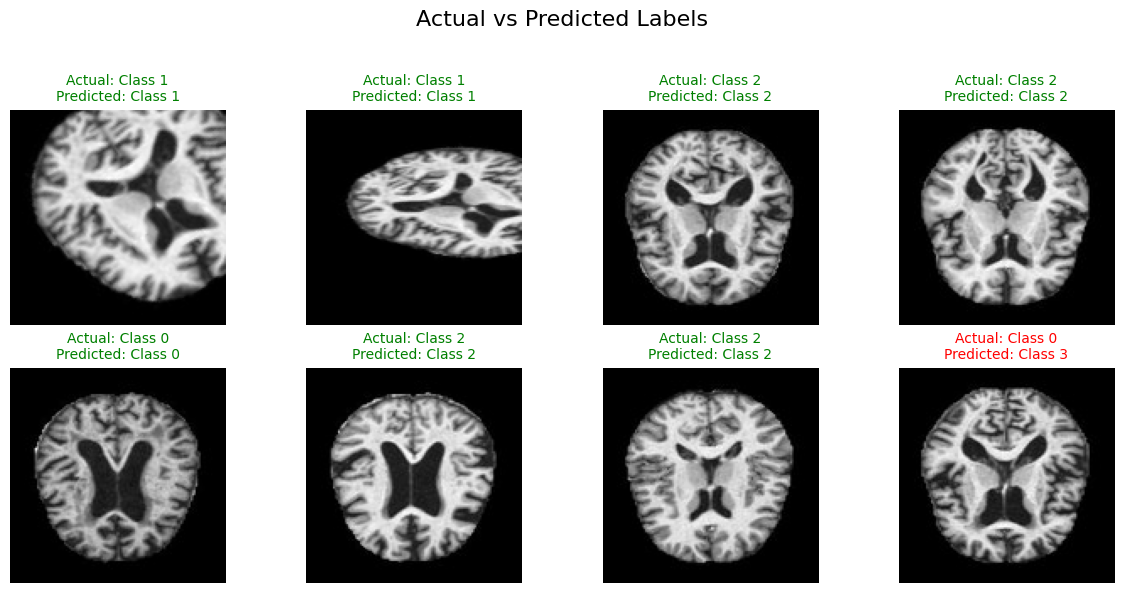

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Select 8 random indices from the validation set
num_samples = 8
random_indices = random.sample(range(len(X_test)), num_samples)

# Extract the images and actual labels
random_images = X_test[random_indices]
actual_labels = np.argmax(y_test[random_indices], axis=1)  # Convert one-hot labels to class index

# Get model predictions
predicted_labels = np.argmax(model.predict(random_images), axis=1)

# Define class names (Modify this based on your dataset)
class_names = ["Class 0", "Class 1", "Class 2", "Class 3"]
# Plot the images with actual and predicted labels
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Actual vs Predicted Labels", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = np.squeeze(random_images[i])  # Remove extra dimensions if needed
    ax.imshow(img, cmap="gray")  # Change 'gray' if images are in color
    ax.axis("off")

    # Title with actual and predicted class
    actual_class = class_names[actual_labels[i]]
    predicted_class = class_names[predicted_labels[i]]

    title_color = "green" if actual_labels[i] == predicted_labels[i] else "red"
    ax.set_title(f"Actual: {actual_class}\nPredicted: {predicted_class}", color=title_color, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()